# Pipeline v3 — Spatial + CCA + Parallélisme + GridSearch + ROC

**Améliorations apportées :**
- ✅ **CCA** (Analyse Canonique des Corrélations) avec visualisation des corrélations canoniques
- ✅ **Parallélisme** via `joblib.Parallel` pour l'extraction de features (×N_JOBS accélération)
- ✅ **GridSearchCV** sur le meilleur algorithme détecté automatiquement
- ✅ **Matrice de Confusion** annotée avec Seaborn
- ✅ **Courbe ROC** avec calcul de l'AUC

## Cell 1 — Imports

In [1]:
import os, warnings, copy, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag

# ── Skimage ──────────────────────────────────────────────────────
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray
from skimage import io, transform, filters
from skimage.filters import threshold_otsu, threshold_local, scharr
from skimage.measure import label
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi
from scipy.stats import pearsonr
from scipy.spatial.distance import cosine, cityblock, chebyshev, canberra, braycurtis

# ── Sklearn ───────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectFromModel, VarianceThreshold
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, roc_auc_score
)
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.utils import shuffle
from sklearn.pipeline import Pipeline

# ── Parallélisme ─────────────────────────────────────────────────
from joblib import Parallel, delayed

try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    VADER_OK = True
    vader = SentimentIntensityAnalyzer()
except ImportError:
    VADER_OK = False

warnings.filterwarnings('ignore')
for r in ['punkt','stopwords','wordnet','omw-1.4',
          'averaged_perceptron_tagger_eng','punkt_tab']:
    nltk.download(r, quiet=True)

lemmatizer = WordNetLemmatizer()
STOP = set(stopwords.words('english'))
N_JOBS = -1   # utilise tous les cœurs disponibles

print('✅ Imports OK — Pipeline v3 Spatial + CCA + Parallélisme + GridSearch')

✅ Imports OK — Pipeline v3 Spatial + CCA + Parallélisme + GridSearch


## Cell 2 — Chargement des données

In [2]:
DATA_DIR = '../data/processed'

def load_split(split_name):
    texts, img_paths, labels = [], [], []
    for label_id, cat in enumerate(['incoherent', 'coherent']):
        folder = os.path.join(DATA_DIR, split_name, cat)
        if not os.path.exists(folder):
            print(f'⚠️  Dossier {folder} non trouvé.')
            continue
        for f in sorted(os.listdir(folder)):
            if f.endswith('.txt'):
                with open(os.path.join(folder, f), 'r', encoding='utf-8') as fh:
                    texts.append(fh.read().strip())
                img_paths.append(os.path.join(folder, f.replace('.txt', '.jpg')))
                labels.append(label_id)
    texts, img_paths, labels = shuffle(
        texts, img_paths, np.array(labels), random_state=42
    )
    return np.array(texts), np.array(img_paths), labels

print('📂 Chargement des splits...')
t_train, p_train, y_train = load_split('train')
t_val,   p_val,   y_val   = load_split('validation')
t_test,  p_test,  y_test  = load_split('test')

print(f'  Train      : {len(t_train)} exemples')
print(f'  Validation : {len(t_val)} exemples')
print(f'  Test       : {len(t_test)} exemples')
print(f'  Balance train : {np.bincount(y_train)} (inc / coh)')

📂 Chargement des splits...
  Train      : 7000 exemples
  Validation : 1500 exemples
  Test       : 1500 exemples
  Balance train : [3505 3495] (inc / coh)


## Cell 3 — Fonctions de segmentation spatiale (grille 3×3)

In [3]:
IMG_SIZE   = (192, 192)
GRID_N     = 3
HOG_PIXELS = 8
LBP_RADIUS = 2
LBP_POINTS = 8 * LBP_RADIUS
N_HSV_BINS = 16

def get_grid_zones(img, n=GRID_N):
    h, w = img.shape[:2]
    zh, zw = h // n, w // n
    return [(r, c, img[r*zh:(r+1)*zh, c*zw:(c+1)*zw])
            for r in range(n) for c in range(n)]

def segment_canny(gray, low=50, high=150):
    g8 = (gray * 255).astype(np.uint8)
    return cv2.Canny(g8, low, high).astype(float) / 255.0

def segment_deriche(gray):
    mag = scharr(gray)
    return (mag - mag.min()) / (mag.max() - mag.min() + 1e-8)

def segment_adaptive(gray):
    g8 = (gray * 255).astype(np.uint8)
    block = min(35, (min(gray.shape[:2]) // 4) | 1)
    thresh = threshold_local(g8, block_size=block, offset=10)
    return (g8 > thresh).astype(float)

def segment_otsu(gray):
    thresh = threshold_otsu(gray)
    return (gray > thresh).astype(float)

def segment_watershed(gray):
    binary = segment_otsu(gray).astype(bool)
    distance = ndi.distance_transform_edt(binary)
    min_d = max(5, min(gray.shape) // 10)
    coords = peak_local_max(distance, min_distance=min_d, labels=binary)
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = ndi.label(mask)
    labels_ws = watershed(-distance, markers, mask=binary)
    return labels_ws, markers

def compute_saliency_map(gray):
    g8 = (gray * 255).astype(np.float32)
    fft = np.fft.fft2(g8)
    log_amp = np.log(np.abs(fft) + 1e-8)
    kernel = np.ones((3,3), np.float32) / 9
    smooth = cv2.filter2D(log_amp, -1, kernel)
    spectral_residual = log_amp - smooth
    reconstructed = np.fft.ifft2(
        np.exp(spectral_residual + 1j * np.angle(fft))
    ).real
    saliency = cv2.GaussianBlur(reconstructed**2, (9,9), 2.5)
    return (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

print('✅ Fonctions segmentation définies.')

✅ Fonctions segmentation définies.


## Cell 4 — Extraction features IMAGE (parallélisée avec joblib)

In [4]:
def extract_image_features_single(img_path):
    """
    Extrait toutes les features d'une seule image.
    Fonction conçue pour être appelée en parallèle via joblib.Parallel.
    """
    try:
        img = io.imread(img_path)
        if img.ndim == 2:          img = np.stack([img]*3, axis=-1)
        if img.shape[2] == 4:      img = img[:,:,:3]
        img = (transform.resize(img, IMG_SIZE, anti_aliasing=True) * 255).astype(np.uint8)
        gray = rgb2gray(img)

        # ── 1. HOG + HSV + LBP par zone 3×3 (9 zones) ──────────
        zone_feats = []
        img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        for r, c, zone in get_grid_zones(img):
            gray_zone = rgb2gray(zone)
            # HOG local
            hog_f = hog(gray_zone, orientations=8, pixels_per_cell=(HOG_PIXELS, HOG_PIXELS),
                        cells_per_block=(2,2), feature_vector=True)
            # HSV local
            hsv_zone = img_hsv[r*(IMG_SIZE[0]//GRID_N):(r+1)*(IMG_SIZE[0]//GRID_N),
                                c*(IMG_SIZE[1]//GRID_N):(c+1)*(IMG_SIZE[1]//GRID_N)]
            h_hist = np.histogram(hsv_zone[:,:,0], bins=N_HSV_BINS, range=(0,180), density=True)[0]
            s_hist = np.histogram(hsv_zone[:,:,1], bins=N_HSV_BINS, range=(0,255), density=True)[0]
            v_hist = np.histogram(hsv_zone[:,:,2], bins=N_HSV_BINS, range=(0,255), density=True)[0]
            # LBP local
            lbp = local_binary_pattern(gray_zone, LBP_POINTS, LBP_RADIUS, method='uniform')
            lbp_hist = np.histogram(lbp, bins=LBP_POINTS+2, range=(0, LBP_POINTS+2), density=True)[0]
            zone_feats.append(np.concatenate([hog_f, h_hist, s_hist, v_hist, lbp_hist]))
        zone_vector = np.concatenate(zone_feats)

        # ── 2. Cartes de segmentation → densité par zone ─────────
        canny_map   = segment_canny(gray)
        deriche_map = segment_deriche(gray)
        otsu_map    = segment_otsu(gray)
        adapt_map   = segment_adaptive(gray)
        sal_map     = compute_saliency_map(gray)

        def zone_density(map2d):
            zh, zw = IMG_SIZE[0]//GRID_N, IMG_SIZE[1]//GRID_N
            return np.array([map2d[r*zh:(r+1)*zh, c*zw:(c+1)*zw].mean()
                             for r in range(GRID_N) for c in range(GRID_N)])

        seg_feats = np.concatenate([
            zone_density(canny_map),
            zone_density(deriche_map),
            zone_density(otsu_map),
            zone_density(adapt_map),
            zone_density(sal_map),
        ])  # 5 × 9 = 45

        # ── 3. Features spatiales globales ───────────────────────
        # Centre de masse des contours
        ys, xs = np.where(canny_map > 0.1)
        cy_norm = ys.mean() / IMG_SIZE[0] if len(ys) > 0 else 0.5
        cx_norm = xs.mean() / IMG_SIZE[1] if len(xs) > 0 else 0.5
        cy_std  = ys.std()  / IMG_SIZE[0] if len(ys) > 0 else 0.0
        cx_std  = xs.std()  / IMG_SIZE[1] if len(xs) > 0 else 0.0

        # Asymétries gauche/droite et haut/bas
        h2, w2 = IMG_SIZE[0]//2, IMG_SIZE[1]//2
        asym_lr_canny = canny_map[:, :w2].mean() - canny_map[:, w2:].mean()
        asym_tb_canny = canny_map[:h2, :].mean() - canny_map[h2:, :].mean()
        asym_lr_sal   = sal_map[:, :w2].mean()   - sal_map[:, w2:].mean()
        asym_tb_sal   = sal_map[:h2, :].mean()   - sal_map[h2:, :].mean()

        # Asymétries couleur HSV haut/bas
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(float)
        top_hue = hsv[:h2, :, 0].mean() / 180.0
        bot_hue = hsv[h2:, :, 0].mean() / 180.0
        top_sat = hsv[:h2, :, 1].mean() / 255.0
        bot_sat = hsv[h2:, :, 1].mean() / 255.0
        top_val = hsv[:h2, :, 2].mean() / 255.0
        bot_val = hsv[h2:, :, 2].mean() / 255.0
        asym_hue = top_hue - bot_hue
        asym_sat = top_sat - bot_sat
        asym_val = top_val - bot_val

        # Watershed : nombre de régions
        ws_map, _ = segment_watershed(gray)
        n_regions = ws_map.max()

        # Saliency globale : entropie
        sal_flat = sal_map.flatten()
        sal_entr = -np.sum(sal_flat * np.log(sal_flat + 1e-8)) / len(sal_flat)

        spatial_scalars = np.array([
            cy_norm, cx_norm, cy_std, cx_std,
            asym_lr_canny, asym_tb_canny,
            asym_lr_sal,   asym_tb_sal,
            asym_hue, asym_sat, asym_val,
            top_hue, bot_hue, top_sat, bot_sat, top_val, bot_val,
            float(n_regions) / 100.0, sal_entr,
            sal_map.mean(), sal_map.max(), sal_map.std(),
        ])  # 22 scalars

        # ── 4. HOG global ────────────────────────────────────────
        hog_global = hog(gray, orientations=9, pixels_per_cell=(16,16),
                         cells_per_block=(2,2), feature_vector=True)

        return np.concatenate([zone_vector, seg_feats, spatial_scalars, hog_global])

    except Exception as e:
        # En cas d'erreur (image corrompue), retourner des zéros
        return None


def extract_image_features_parallel(img_paths, desc=''):
    """
    ✨ PARALLÉLISME : extraction des features images sur tous les cœurs.
    joblib.Parallel avec backend='loky' (multiprocessing sécurisé).
    """
    print(f'  ⚡ Extraction parallèle {desc} ({len(img_paths)} images, N_JOBS={N_JOBS})...')
    t0 = time.time()

    results = Parallel(n_jobs=N_JOBS, backend='loky', verbose=0)(
        delayed(extract_image_features_single)(p) for p in img_paths
    )

    # Remplacer les None (erreurs) par des zéros
    valid = [r for r in results if r is not None]
    feat_size = valid[0].shape[0] if valid else 100
    results_clean = [
        r if r is not None else np.zeros(feat_size)
        for r in results
    ]

    elapsed = time.time() - t0
    print(f'  ✅ Terminé en {elapsed:.1f}s — shape: {np.array(results_clean).shape}')
    return np.array(results_clean)


print('⚡ Début extraction features images (parallèle)...')
F_img_train = extract_image_features_parallel(p_train, 'TRAIN')
F_img_val   = extract_image_features_parallel(p_val,   'VAL')
F_img_test  = extract_image_features_parallel(p_test,  'TEST')

⚡ Début extraction features images (parallèle)...
  ⚡ Extraction parallèle TRAIN (7000 images, N_JOBS=-1)...
  ✅ Terminé en 231.6s — shape: (7000, 19129)
  ⚡ Extraction parallèle VAL (1500 images, N_JOBS=-1)...
  ✅ Terminé en 47.0s — shape: (1500, 19129)
  ⚡ Extraction parallèle TEST (1500 images, N_JOBS=-1)...
  ✅ Terminé en 44.9s — shape: (1500, 19129)


## Cell 5 — Extraction features TEXTE (parallélisée)

In [6]:
# Mots spatiaux / couleurs / scène
SPATIAL_WORDS = {
    'left':0,'right':1,'top':2,'bottom':3,'center':4,
    'behind':5,'front':6,'above':7,'below':8,'beside':9,
    'near':10,'far':11,'between':12,'around':13,
}
COLOR_WORDS   = {'red','blue','green','yellow','white','black',
                 'dark','bright','light','color','sky','ocean'}
SKY_WORDS     = {'sky','cloud','sun','sunset','sunrise','blue','clouds'}
POSITION_EXPECT = [
    ('sky','cloud','sun','above','top','upper'),     # → obj en haut
    ('ground','floor','bottom','under','below'),      # → obj en bas
    ('center','middle','front'),                      # → obj au centre
]

def extract_text_features_single(text):
    """
    Extrait les features statistiques/spatiales d'un texte.
    Conçue pour être appelée en parallèle via joblib.Parallel.
    """
    tokens = word_tokenize(text.lower())
    tokens_clean = [lemmatizer.lemmatize(t) for t in tokens
                    if t.isalpha() and t not in STOP]
    token_set = set(tokens_clean)

    # Stats de base
    n_tokens   = len(tokens)
    n_unique   = len(set(tokens))
    type_token = n_unique / (n_tokens + 1)
    avg_len    = np.mean([len(t) for t in tokens]) if tokens else 0
    n_sent     = len(text.split('.'))

    # POS tags
    pos = pos_tag(tokens_clean[:50])  # limiter pour la vitesse
    n_nouns = sum(1 for _, p in pos if p.startswith('NN'))
    n_verbs = sum(1 for _, p in pos if p.startswith('VB'))
    n_adj   = sum(1 for _, p in pos if p.startswith('JJ'))

    # Sentiment
    if VADER_OK:
        scores = vader.polarity_scores(text)
        sentiment = [scores['pos'], scores['neg'], scores['neu'], scores['compound']]
    else:
        sentiment = [0.0, 0.0, 1.0, 0.0]

    # Mots spatiaux
    spatial_counts = np.zeros(len(SPATIAL_WORDS))
    for w, idx in SPATIAL_WORDS.items():
        spatial_counts[idx] = float(w in token_set)

    # Mots couleurs
    n_color_words = sum(1 for w in token_set if w in COLOR_WORDS)
    n_sky_words   = sum(1 for w in token_set if w in SKY_WORDS)

    # Attentes positionnelles
    exp_top    = sum(1 for w in token_set if w in POSITION_EXPECT[0])
    exp_bottom = sum(1 for w in token_set if w in POSITION_EXPECT[1])
    exp_center = sum(1 for w in token_set if w in POSITION_EXPECT[2])

    # Drapeaux mots spatiaux
    has_left   = float('left'   in token_set)
    has_right  = float('right'  in token_set)
    has_top    = float('top'    in token_set or 'above' in token_set)
    has_bottom = float('bottom' in token_set or 'below' in token_set)
    has_center = float('center' in token_set or 'middle' in token_set)

    return np.array([
        n_tokens, n_unique, type_token, avg_len, n_sent,
        n_nouns, n_verbs, n_adj,
        *sentiment,
        *spatial_counts,
        n_color_words, n_sky_words,
        exp_top, exp_bottom, exp_center,
        has_left, has_right, has_top, has_bottom, has_center,
    ], dtype=float)


def extract_text_features_parallel(texts, desc=''):
    """
    ✨ PARALLÉLISME : extraction des features texte sur tous les cœurs.
    """
    print(f'  ⚡ Extraction parallèle texte {desc} ({len(texts)} textes)...')
    t0 = time.time()
    results = Parallel(n_jobs=N_JOBS, backend='loky', verbose=0)(
        delayed(extract_text_features_single)(text) for text in texts
    )
    elapsed = time.time() - t0
    arr = np.array(results)
    print(f'  ✅ Terminé en {elapsed:.1f}s — shape: {arr.shape}')
    return arr


print('📝 Extraction features texte...')
S_train = extract_text_features_parallel(t_train, 'TRAIN')
S_val   = extract_text_features_parallel(t_val,   'VAL')
S_test  = extract_text_features_parallel(t_test,  'TEST')

# TF-IDF (non-parallélisé car sklearn gère en interne)
print('\n📝 TF-IDF...')
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)
TF_train = tfidf.fit_transform(t_train).toarray()
TF_val   = tfidf.transform(t_val).toarray()
TF_test  = tfidf.transform(t_test).toarray()

# Fusionner stats + TF-IDF
F_text_train = np.hstack([S_train, TF_train])
F_text_val   = np.hstack([S_val,   TF_val])
F_text_test  = np.hstack([S_test,  TF_test])
print(f'Features texte : {F_text_train.shape}')

📝 Extraction features texte...
  ⚡ Extraction parallèle texte TRAIN (7000 textes)...
  ✅ Terminé en 25.4s — shape: (7000, 36)
  ⚡ Extraction parallèle texte VAL (1500 textes)...
  ✅ Terminé en 0.7s — shape: (1500, 36)
  ⚡ Extraction parallèle texte TEST (1500 textes)...
  ✅ Terminé en 0.8s — shape: (1500, 36)

📝 TF-IDF...
Features texte : (7000, 5036)


## Cell 6 — CCA (Analyse Canonique des Corrélations)

🔬 Nettoyage des features...
  Image  : 19129  → 19128
  Texte  : 5036 → 5029
  Image après dédup : 18995 features

🔵 PCA pré-CCA (128 dims)...
  Variance expliquée Image : 0.385
  Variance expliquée Texte : 0.170

🔬 CCA (64 composantes canoniques)...

📊 Corrélations canoniques (top 15) :
   Composante  1 : r = 0.3576
   Composante  2 : r = 0.3066
   Composante  3 : r = 0.2797
   Composante  4 : r = 0.2365
   Composante  5 : r = 0.2143
   Composante  6 : r = 0.2005
   Composante  7 : r = 0.2190
   Composante  8 : r = 0.2006
   Composante  9 : r = 0.1746
   Composante 10 : r = 0.1807
   Composante 11 : r = 0.1837
   Composante 12 : r = 0.1889
   Composante 13 : r = 0.1759
   Composante 14 : r = 0.1791
   Composante 15 : r = 0.1626


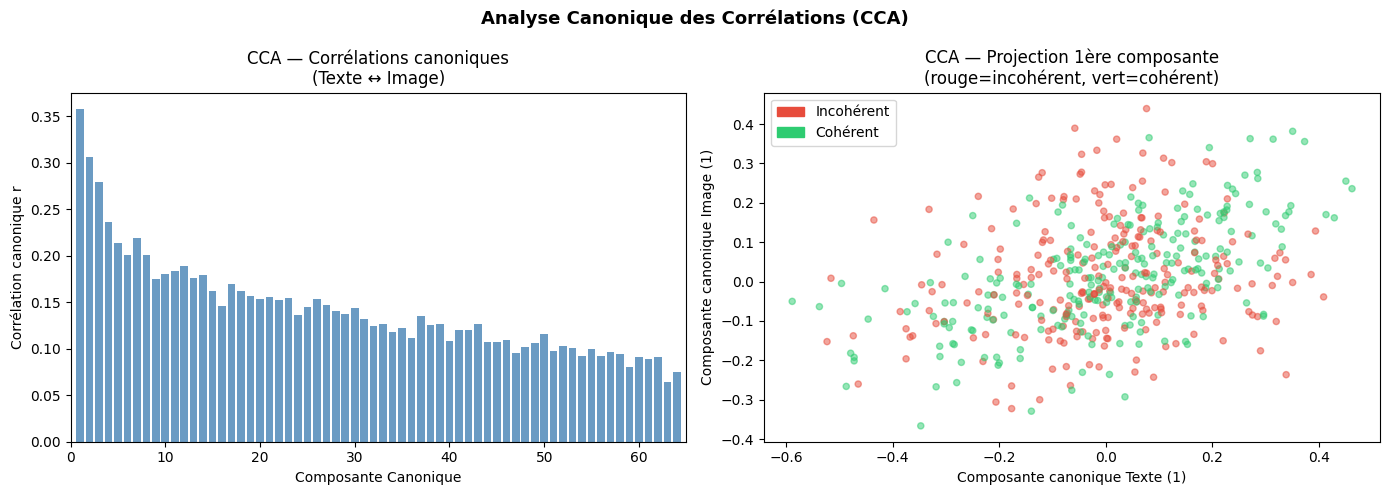


✅ CCA terminé — shape vecteurs : (7000, 64)


In [7]:
print('🔬 Nettoyage des features...')

# ── VarianceThreshold ────────────────────────────────────────────
vt_img  = VarianceThreshold(threshold=1e-6)
vt_text = VarianceThreshold(threshold=1e-6)
F_img_train_vt  = vt_img.fit_transform(F_img_train)
F_img_val_vt    = vt_img.transform(F_img_val)
F_img_test_vt   = vt_img.transform(F_img_test)
F_text_train_vt = vt_text.fit_transform(F_text_train)
F_text_val_vt   = vt_text.transform(F_text_val)
F_text_test_vt  = vt_text.transform(F_text_test)
print(f'  Image  : {F_img_train.shape[1]}  → {F_img_train_vt.shape[1]}')
print(f'  Texte  : {F_text_train.shape[1]} → {F_text_train_vt.shape[1]}')

# ── StandardScaler ───────────────────────────────────────────────
sc_img  = StandardScaler()
sc_text = StandardScaler()
F_img_train_s  = sc_img.fit_transform(F_img_train_vt)
F_img_val_s    = sc_img.transform(F_img_val_vt)
F_img_test_s   = sc_img.transform(F_img_test_vt)
F_text_train_s = sc_text.fit_transform(F_text_train_vt)
F_text_val_s   = sc_text.transform(F_text_val_vt)
F_text_test_s  = sc_text.transform(F_text_test_vt)

# ── Déduplication corrélation ────────────────────────────────────
def remove_correlated(X, threshold=0.95):
    X_s = X[:min(500, len(X))]
    corr = np.corrcoef(X_s.T)
    np.fill_diagonal(corr, 0)
    to_drop = set()
    for i in range(corr.shape[0]):
        if i in to_drop: continue
        for j in range(i+1, corr.shape[1]):
            if abs(corr[i,j]) > threshold: to_drop.add(j)
    return [i for i in range(X.shape[1]) if i not in to_drop]

keep_img = remove_correlated(F_img_train_s)
F_img_train_s = F_img_train_s[:, keep_img]
F_img_val_s   = F_img_val_s[:,   keep_img]
F_img_test_s  = F_img_test_s[:,  keep_img]
print(f'  Image après dédup : {len(keep_img)} features')

# ── PCA pré-CCA ──────────────────────────────────────────────────
K_pre = 128
K_cca = 64
print(f'\n🔵 PCA pré-CCA ({K_pre} dims)...')
pca_img_pre  = PCA(n_components=min(K_pre, F_img_train_s.shape[1]),  random_state=42)
pca_text_pre = PCA(n_components=min(K_pre, F_text_train_s.shape[1]), random_state=42)
P_img_train  = pca_img_pre.fit_transform(F_img_train_s)
P_img_val    = pca_img_pre.transform(F_img_val_s)
P_img_test   = pca_img_pre.transform(F_img_test_s)
P_text_train = pca_text_pre.fit_transform(F_text_train_s)
P_text_val   = pca_text_pre.transform(F_text_val_s)
P_text_test  = pca_text_pre.transform(F_text_test_s)

print(f'  Variance expliquée Image : {pca_img_pre.explained_variance_ratio_.sum():.3f}')
print(f'  Variance expliquée Texte : {pca_text_pre.explained_variance_ratio_.sum():.3f}')

# ══════════════════════════════════════════════════════════════════
# 🔬 CCA — Analyse Canonique des Corrélations
# ══════════════════════════════════════════════════════════════════
print(f'\n🔬 CCA ({K_cca} composantes canoniques)...')
cca = CCA(n_components=K_cca, max_iter=1000)
cca.fit(P_text_train, P_img_train)

V_text_train, V_img_train = cca.transform(P_text_train, P_img_train)
V_text_val,   V_img_val   = cca.transform(P_text_val,   P_img_val)
V_text_test,  V_img_test  = cca.transform(P_text_test,  P_img_test)

# Normalisation L2
V_img_train  = normalize(V_img_train);  V_img_val   = normalize(V_img_val)
V_img_test   = normalize(V_img_test);   V_text_train = normalize(V_text_train)
V_text_val   = normalize(V_text_val);   V_text_test  = normalize(V_text_test)

# ── Corrélations canoniques (diagnostic) ─────────────────────────
print('\n📊 Corrélations canoniques (top 15) :')
canonical_corrs = []
for i in range(min(K_cca, 15)):
    r = np.corrcoef(V_text_train[:,i], V_img_train[:,i])[0,1]
    canonical_corrs.append(r)
    print(f'   Composante {i+1:2d} : r = {r:.4f}')

# ── Visualisation corrélations canoniques ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart corrélations
all_corrs = []
for i in range(K_cca):
    r = np.corrcoef(V_text_train[:,i], V_img_train[:,i])[0,1]
    all_corrs.append(r)

axes[0].bar(range(1, K_cca+1), all_corrs, color='steelblue', alpha=0.8)
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0].set_xlabel('Composante Canonique')
axes[0].set_ylabel('Corrélation canonique r')
axes[0].set_title('CCA — Corrélations canoniques\n(Texte ↔ Image)')
axes[0].set_xlim([0, K_cca+1])

# Scatter 1ère composante canonique
n_show = min(500, len(V_text_train))
colors = ['#e74c3c' if y==0 else '#2ecc71' for y in y_train[:n_show]]
axes[1].scatter(V_text_train[:n_show, 0], V_img_train[:n_show, 0],
                c=colors, alpha=0.5, s=20)
axes[1].set_xlabel('Composante canonique Texte (1)')
axes[1].set_ylabel('Composante canonique Image (1)')
axes[1].set_title('CCA — Projection 1ère composante\n(rouge=incohérent, vert=cohérent)')
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='#e74c3c', label='Incohérent'),
    Patch(color='#2ecc71', label='Cohérent')
])

plt.suptitle('Analyse Canonique des Corrélations (CCA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✅ CCA terminé — shape vecteurs : {V_text_train.shape}')

## Cell 7 — Construction du dataset final (features de distance CCA + cross-spatial)

In [8]:
# Index dans S (features stats texte) pour les features spatiales
IDX_EXP = 18  # exp_top, exp_bottom, exp_center
IDX_HAS = 21  # has_left, has_right, ...

def build_cross_features_single(fi, st, vt, vi):
    """
    Construit le vecteur de distance CCA + cross-features spatiaux
    pour une paire (image, texte).
    """
    # ── Distances dans l'espace CCA ──────────────────────────────
    t, v = vt, vi
    d = t - v
    product  = t * v
    abs_diff = np.abs(d)

    dist_cosine     = float(cosine(t, v))              if np.any(t) and np.any(v) else 1.0
    cos_sim         = 1.0 - dist_cosine
    dist_euclidean  = float(np.linalg.norm(d))
    dist_manhattan  = float(cityblock(t, v))
    dist_chebyshev  = float(chebyshev(t, v))
    dist_canberra   = float(canberra(t+1e-8, v+1e-8))
    dist_braycurtis = float(braycurtis(t+1e-8, v+1e-8))
    dot_product     = float(np.dot(t, v))
    angle           = float(np.arccos(np.clip(cos_sim, -1, 1)))
    pearson_r       = float(pearsonr(t, v)[0]) if len(t) > 2 else 0.0
    norm_ratio      = float(np.linalg.norm(t) / (np.linalg.norm(v) + 1e-8))
    proj_scalar     = dot_product / (np.linalg.norm(v) + 1e-8)
    orth_norm       = float(np.linalg.norm(d - proj_scalar * v / (np.linalg.norm(v) + 1e-8)))
    diff_std        = float(d.std())

    # ── Cross-features spatiaux texte ↔ image ────────────────────
    text_exp_top    = float(st[IDX_EXP])     if len(st) > IDX_EXP+2   else 0.0
    text_exp_bottom = float(st[IDX_EXP+1])   if len(st) > IDX_EXP+2   else 0.0
    text_exp_center = float(st[IDX_EXP+2])   if len(st) > IDX_EXP+2   else 0.0
    text_has_left   = float(st[IDX_HAS])     if len(st) > IDX_HAS+4   else 0.0
    text_has_right  = float(st[IDX_HAS+1])   if len(st) > IDX_HAS+4   else 0.0

    N_HOG  = 81
    N_SPAT = 22
    if len(fi) > N_HOG + N_SPAT:
        spat = fi[-(N_HOG + N_SPAT):-N_HOG]
        cy_norm       = spat[0]  if len(spat) > 0  else 0.5
        cx_norm       = spat[1]  if len(spat) > 1  else 0.5
        asym_lr_canny = spat[4]  if len(spat) > 4  else 0.0
        asym_tb_canny = spat[5]  if len(spat) > 5  else 0.0
        asym_tb_sal   = spat[7]  if len(spat) > 7  else 0.0
        asym_hue      = spat[8]  if len(spat) > 8  else 0.0
        top_hue       = spat[11] if len(spat) > 11 else 0.0
        bot_hue       = spat[12] if len(spat) > 12 else 0.0
    else:
        cy_norm = cx_norm = 0.5
        asym_lr_canny = asym_tb_canny = asym_tb_sal = asym_hue = 0.0
        top_hue = bot_hue = 0.0

    cross_top_coherence    = text_exp_top    * (-asym_tb_canny)
    cross_bottom_coherence = text_exp_bottom * asym_tb_canny
    cross_left_right       = (text_has_left - text_has_right) * asym_lr_canny
    has_sky_word = int(any(w in ['sky','cloud','blue','sun','sunset','sunrise']
                           for w in st.astype(str)))
    sky_hue_match = has_sky_word * (1 - abs(top_hue - 0.56))
    pos_coherence = (text_exp_bottom - text_exp_top) * (cy_norm - 0.5)

    cross_feats = np.array([
        cross_top_coherence, cross_bottom_coherence,
        cross_left_right, sky_hue_match, pos_coherence,
        text_exp_top * top_hue, text_exp_bottom * bot_hue,
        cx_norm, cy_norm,
    ])

    scalars = np.array([
        dist_cosine, cos_sim, dist_euclidean, dist_manhattan, dist_chebyshev,
        dist_canberra, dist_braycurtis, dot_product, angle, pearson_r,
        norm_ratio, proj_scalar, orth_norm, diff_std,
        d.mean(), d.max(), d.min(),
    ])

    return np.concatenate([scalars, cross_feats, d, product, abs_diff])


def build_cross_features_parallel(F_img, S, V_text, V_img, desc=''):
    """
    ✨ PARALLÉLISME : construction des features de distance en parallèle.
    """
    print(f'  ⚡ Build cross-features {desc} ({len(F_img)} exemples)...')
    t0 = time.time()
    results = Parallel(n_jobs=N_JOBS, backend='loky', verbose=0)(
        delayed(build_cross_features_single)(fi, st, vt, vi)
        for fi, st, vt, vi in zip(F_img, S, V_text, V_img)
    )
    elapsed = time.time() - t0
    arr = np.array(results)
    print(f'  ✅ {desc} — shape: {arr.shape} ({elapsed:.1f}s)')
    return arr


print('🔨 Construction datasets finaux...')
D_train = build_cross_features_parallel(F_img_train, S_train, V_text_train, V_img_train, 'TRAIN')
D_val   = build_cross_features_parallel(F_img_val,   S_val,   V_text_val,   V_img_val,   'VAL')
D_test  = build_cross_features_parallel(F_img_test,  S_test,  V_text_test,  V_img_test,  'TEST')

# Normalisation finale
sc_dist = StandardScaler()
X_train = sc_dist.fit_transform(D_train)
X_val   = sc_dist.transform(D_val)
X_test  = sc_dist.transform(D_test)

vt_final = VarianceThreshold(threshold=1e-4)
X_train  = vt_final.fit_transform(X_train)
X_val    = vt_final.transform(X_val)
X_test   = vt_final.transform(X_test)
print(f'  Après VT : {X_train.shape[1]} features')

# Sélection par RF
print('  Sélection de features (RF)...')
selector = SelectFromModel(
    RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=N_JOBS),
    threshold='mean'
)
selector.fit(X_train, y_train)
X_train_sel = selector.transform(X_train)
X_val_sel   = selector.transform(X_val)
X_test_sel  = selector.transform(X_test)
print(f'  Après sélection RF : {X_train_sel.shape[1]} features ({(1-X_train_sel.shape[1]/X_train.shape[1])*100:.1f}% réduction)')

🔨 Construction datasets finaux...
  ⚡ Build cross-features TRAIN (7000 exemples)...
  ✅ TRAIN — shape: (7000, 218) (25.6s)
  ⚡ Build cross-features VAL (1500 exemples)...
  ✅ VAL — shape: (1500, 218) (4.8s)
  ⚡ Build cross-features TEST (1500 exemples)...
  ✅ TEST — shape: (1500, 218) (6.0s)
  Après VT : 214 features
  Sélection de features (RF)...
  Après sélection RF : 35 features (83.6% réduction)


## Cell 8 — Comparaison des modèles (sélection du meilleur)

In [9]:
MODELS = {
    'Logistic Regression':  LogisticRegression(max_iter=2000, C=1.0, random_state=42),
    'Linear SVM':           LinearSVC(max_iter=5000, C=1.0, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=N_JOBS),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42),
}

def eval_models(X_tr, X_vl, y_tr, y_vl, label=''):
    print(f'\n── {label} ──')
    print(f'{"Modèle":<25} {"CV5":>8} {"±":>6} {"ValAcc":>8} {"ValF1":>8}')
    print('-' * 62)
    results = {}
    for name, mdl in MODELS.items():
        m = copy.deepcopy(mdl)
        cv = cross_val_score(m, X_tr, y_tr, cv=5, scoring='accuracy', n_jobs=1)
        m.fit(X_tr, y_tr)
        yp  = m.predict(X_vl)
        acc = accuracy_score(y_vl, yp)
        f1  = f1_score(y_vl, yp)
        print(f'{name:<25} {cv.mean():.4f} {cv.std():.4f} {acc:.4f} {f1:.4f}')
        results[name] = {'cv': cv.mean(), 'cv_std': cv.std(), 'acc': acc, 'f1': f1, 'model': m}
    return results

res_full = eval_models(X_train,     X_val,     y_train, y_val, 'Dataset complet')
res_sel  = eval_models(X_train_sel, X_val_sel, y_train, y_val, 'Dataset sélectionné')

# Meilleur modèle (sur validation accuracy)
all_res = {**res_full, **{n+'[sel]': v for n,v in res_sel.items()}}
best_name = max(all_res, key=lambda k: all_res[k]['acc'])
use_sel   = '[sel]' in best_name
base_name = best_name.replace('[sel]', '')
print(f'\n🏆 Meilleur modèle initial : {best_name}')
print(f'   Val Acc = {all_res[best_name]["acc"]:.4f} | Val F1 = {all_res[best_name]["f1"]:.4f}')


── Dataset complet ──
Modèle                         CV5      ±   ValAcc    ValF1
--------------------------------------------------------------
Logistic Regression       0.6380 0.0142 0.6480 0.6271
Linear SVM                0.6380 0.0143 0.6487 0.6281
Random Forest             0.6413 0.0084 0.6540 0.6041
Gradient Boosting         0.6326 0.0051 0.6533 0.6328

── Dataset sélectionné ──
Modèle                         CV5      ±   ValAcc    ValF1
--------------------------------------------------------------
Logistic Regression       0.6529 0.0104 0.6500 0.6321
Linear SVM                0.6536 0.0116 0.6500 0.6300
Random Forest             0.6519 0.0113 0.6587 0.6284
Gradient Boosting         0.6446 0.0076 0.6387 0.6226

🏆 Meilleur modèle initial : Random Forest[sel]
   Val Acc = 0.6587 | Val F1 = 0.6284


## Cell 9 — GridSearchCV sur le meilleur algorithme

In [10]:
# ══════════════════════════════════════════════════════════════════
# GridSearchCV — Paramètres selon le type de meilleur modèle
# ══════════════════════════════════════════════════════════════════

X_tr_gs = X_train_sel if use_sel else X_train
X_vl_gs = X_val_sel   if use_sel else X_val

PARAM_GRIDS = {
    'Logistic Regression': {
        'C':       [0.01, 0.1, 1.0, 5.0, 10.0, 50.0],
        'solver':  ['lbfgs', 'saga'],
        'penalty': ['l2'],
    },
    'Linear SVM': {
        'C':    [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
        'loss': ['squared_hinge'],
    },
    'Random Forest': {
        'n_estimators':      [100, 300, 500],
        'max_depth':         [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'max_features':      ['sqrt', 'log2'],
    },
    'Gradient Boosting': {
        'n_estimators':  [100, 200, 300],
        'max_depth':     [3, 4, 5, 6],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample':     [0.8, 1.0],
    },
}

BASE_MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=3000, random_state=42),
    'Linear SVM':          LinearSVC(max_iter=5000, random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42, n_jobs=N_JOBS),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
}

print(f'\n🔍 GridSearchCV sur : {base_name}')
print(f'   Dataset : {"sélectionné" if use_sel else "complet"} — shape {X_tr_gs.shape}')
print(f'   Paramètres testés : {PARAM_GRIDS[base_name]}')

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(
    estimator   = BASE_MODELS[base_name],
    param_grid  = PARAM_GRIDS[base_name],
    cv          = cv_strat,
    scoring     = 'accuracy',
    n_jobs      = N_JOBS,
    verbose     = 1,
    refit       = True,
    return_train_score = True,
)

t0 = time.time()
gs.fit(X_tr_gs, y_train)
elapsed = time.time() - t0

print(f'\n✅ GridSearch terminé en {elapsed:.1f}s')
print(f'   Meilleurs paramètres : {gs.best_params_}')
print(f'   Best CV score       : {gs.best_score_:.4f}')

# Validation du modèle optimisé
best_model = gs.best_estimator_
y_pred_val_opt = best_model.predict(X_vl_gs)
val_acc_opt = accuracy_score(y_val, y_pred_val_opt)
val_f1_opt  = f1_score(y_val, y_pred_val_opt)
print(f'   Val Acc (optimisé)  : {val_acc_opt:.4f}')
print(f'   Val F1  (optimisé)  : {val_f1_opt:.4f}')

# Tableau des résultats GridSearch
gs_results = pd.DataFrame(gs.cv_results_).sort_values('mean_test_score', ascending=False)
print(f'\n📋 Top-10 configurations :')
cols_show = ['params','mean_test_score','std_test_score','mean_train_score']
print(gs_results[cols_show].head(10).to_string(index=False))


🔍 GridSearchCV sur : Random Forest
   Dataset : sélectionné — shape (7000, 35)
   Paramètres testés : {'n_estimators': [100, 300, 500], 'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10], 'max_features': ['sqrt', 'log2']}
Fitting 5 folds for each of 72 candidates, totalling 360 fits

✅ GridSearch terminé en 679.5s
   Meilleurs paramètres : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
   Best CV score       : 0.6530
   Val Acc (optimisé)  : 0.6480
   Val F1  (optimisé)  : 0.6229

📋 Top-10 configurations :
                                                                                   params  mean_test_score  std_test_score  mean_train_score
   {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}         0.653000        0.007497          0.999893
   {'max_depth': 20, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 300}         0.653000        0.007497          0.999893
{'max_dept

## Cell 10 — Évaluation finale TEST + Matrice de Confusion + Courbe ROC

══════════════════════════════════════════════════════════════
  RÉSULTAT FINAL — Pipeline v3 + CCA + GridSearch
  Modèle      : Random Forest (optimisé)
  Paramètres  : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
  Test Acc    : 0.6633
  Test F1     : 0.6390
══════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

  Incohérent       0.65      0.73      0.68       752
    Cohérent       0.69      0.60      0.64       748

    accuracy                           0.66      1500
   macro avg       0.67      0.66      0.66      1500
weighted avg       0.67      0.66      0.66      1500

  TP=447  TN=548  FP=204  FN=301
  Précision  : 0.6866
  Rappel     : 0.5976
  Spécificité: 0.7287


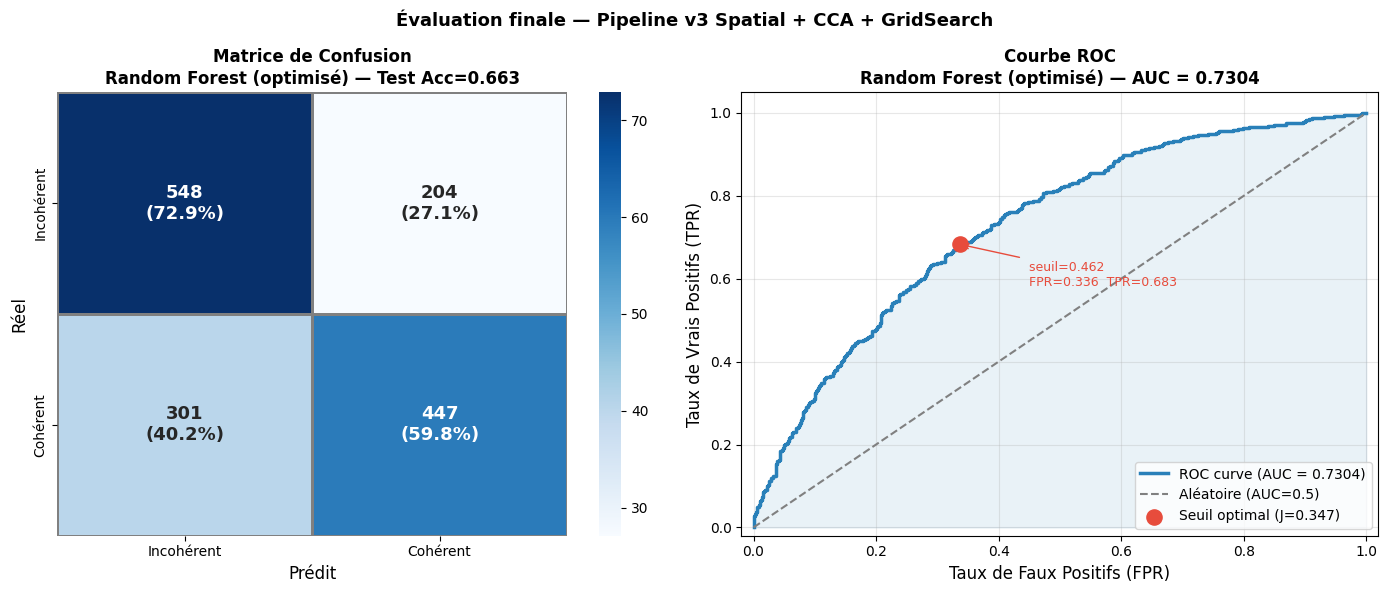


📊 AUC-ROC : 0.7304
   Seuil optimal (Youden) : 0.4618


In [11]:
X_test_final = X_test_sel if use_sel else X_test

y_pred   = best_model.predict(X_test_final)
test_acc = accuracy_score(y_test, y_pred)
test_f1  = f1_score(y_test, y_pred)

print('═' * 62)
print(f'  RÉSULTAT FINAL — Pipeline v3 + CCA + GridSearch')
print(f'  Modèle      : {base_name} (optimisé)')
print(f'  Paramètres  : {gs.best_params_}')
print(f'  Test Acc    : {test_acc:.4f}')
print(f'  Test F1     : {test_f1:.4f}')
print('═' * 62)
print(classification_report(y_test, y_pred, target_names=['Incohérent','Cohérent']))

# ── Probabilités ou scores de décision pour ROC ──────────────────
if hasattr(best_model, 'predict_proba'):
    y_score = best_model.predict_proba(X_test_final)[:, 1]
elif hasattr(best_model, 'decision_function'):
    y_score = best_model.decision_function(X_test_final)
    # Normaliser entre 0 et 1
    y_score = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-8)
else:
    y_score = y_pred.astype(float)

# ══════════════════════════════════════════════════════════════════
# MATRICE DE CONFUSION
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

# Annotation combinée : nombre + pourcentage
annot = np.array([[f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)'
                   for j in range(cm.shape[1])]
                  for i in range(cm.shape[0])])

sns.heatmap(
    cm_pct, annot=annot, fmt='', cmap='Blues',
    xticklabels=['Incohérent','Cohérent'],
    yticklabels=['Incohérent','Cohérent'],
    linewidths=1, linecolor='gray',
    annot_kws={'size': 13, 'weight': 'bold'},
    ax=axes[0]
)
axes[0].set_title(f'Matrice de Confusion\n{base_name} (optimisé) — Test Acc={test_acc:.3f}',
                  fontweight='bold')
axes[0].set_ylabel('Réel', fontsize=12)
axes[0].set_xlabel('Prédit', fontsize=12)

# Métriques dans les cellules diagonales
TP = cm[1,1]; TN = cm[0,0]; FP = cm[0,1]; FN = cm[1,0]
print(f'  TP={TP}  TN={TN}  FP={FP}  FN={FN}')
print(f'  Précision  : {TP/(TP+FP+1e-8):.4f}')
print(f'  Rappel     : {TP/(TP+FN+1e-8):.4f}')
print(f'  Spécificité: {TN/(TN+FP+1e-8):.4f}')

# ══════════════════════════════════════════════════════════════════
# COURBE ROC
# ══════════════════════════════════════════════════════════════════
fpr, tpr, thresholds = roc_curve(y_test, y_score)
auc_score = roc_auc_score(y_test, y_score)

# Point optimal (Youden's J = TPR - FPR)
j_scores = tpr - fpr
best_thresh_idx = np.argmax(j_scores)
best_thresh = thresholds[best_thresh_idx]
best_fpr    = fpr[best_thresh_idx]
best_tpr    = tpr[best_thresh_idx]

axes[1].plot(fpr, tpr, color='#2980b9', lw=2.5,
             label=f'ROC curve (AUC = {auc_score:.4f})')
axes[1].plot([0,1], [0,1], color='gray', lw=1.5, linestyle='--', label='Aléatoire (AUC=0.5)')
axes[1].scatter([best_fpr], [best_tpr], s=120, zorder=5,
                color='#e74c3c', label=f'Seuil optimal (J={j_scores[best_thresh_idx]:.3f})')
axes[1].annotate(f'  seuil={best_thresh:.3f}\n  FPR={best_fpr:.3f}  TPR={best_tpr:.3f}',
                 xy=(best_fpr, best_tpr), xytext=(best_fpr+0.1, best_tpr-0.1),
                 fontsize=9, color='#e74c3c',
                 arrowprops=dict(arrowstyle='->', color='#e74c3c'))

# Zone sous la courbe
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2980b9')

axes[1].set_xlim([-0.02, 1.02])
axes[1].set_ylim([-0.02, 1.05])
axes[1].set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
axes[1].set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
axes[1].set_title(f'Courbe ROC\n{base_name} (optimisé) — AUC = {auc_score:.4f}',
                  fontweight='bold')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Évaluation finale — Pipeline v3 Spatial + CCA + GridSearch',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 AUC-ROC : {auc_score:.4f}')
print(f'   Seuil optimal (Youden) : {best_thresh:.4f}')

## Cell 11 — Analyse GridSearch : courbe de validation

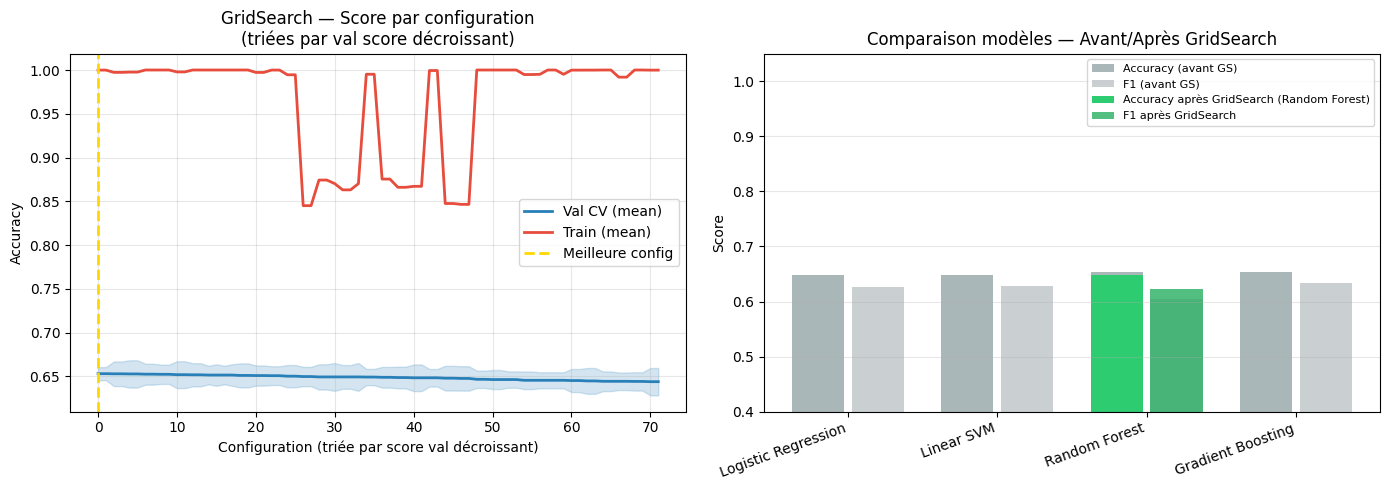

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Courbe train vs val GridSearch ───────────────────────────────
gs_df = pd.DataFrame(gs.cv_results_).sort_values('mean_test_score', ascending=False)

x = range(len(gs_df))
axes[0].plot(x, gs_df['mean_test_score'].values,  label='Val CV (mean)', color='#2980b9', lw=2)
axes[0].fill_between(x,
    gs_df['mean_test_score'] - gs_df['std_test_score'],
    gs_df['mean_test_score'] + gs_df['std_test_score'],
    alpha=0.2, color='#2980b9')
if 'mean_train_score' in gs_df.columns:
    axes[0].plot(x, gs_df['mean_train_score'].values, label='Train (mean)', color='#e74c3c', lw=2)
axes[0].axvline(x=0, color='gold', lw=2, linestyle='--', label='Meilleure config')
axes[0].set_xlabel('Configuration (triée par score val décroissant)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('GridSearch — Score par configuration\n(triées par val score décroissant)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Comparaison avant/après optimisation ─────────────────────────
models_compare = list(MODELS.keys())
val_accs_base  = [all_res.get(n, {}).get('acc', all_res.get(n+'[sel]', {}).get('acc', 0))
                  for n in models_compare]
val_f1s_base   = [all_res.get(n, {}).get('f1', all_res.get(n+'[sel]', {}).get('f1', 0))
                  for n in models_compare]

x_pos = np.arange(len(models_compare))
bars1 = axes[1].bar(x_pos - 0.2, val_accs_base, 0.35, label='Accuracy (avant GS)',
                    color='#95a5a6', alpha=0.8)
bars2 = axes[1].bar(x_pos + 0.2, val_f1s_base,  0.35, label='F1 (avant GS)',
                    color='#bdc3c7', alpha=0.8)

# Ajouter résultat optimisé
best_idx = models_compare.index(base_name) if base_name in models_compare else 0
axes[1].bar(x_pos[best_idx] - 0.2, val_acc_opt, 0.35, color='#2ecc71',
            label=f'Accuracy après GridSearch ({base_name})')
axes[1].bar(x_pos[best_idx] + 0.2, val_f1_opt,  0.35, color='#27ae60', alpha=0.8,
            label='F1 après GridSearch')

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models_compare, rotation=20, ha='right')
axes[1].set_ylabel('Score')
axes[1].set_title('Comparaison modèles — Avant/Après GridSearch')
axes[1].legend(fontsize=8)
axes[1].set_ylim([0.4, 1.05])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('gridsearch_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 12 — Importance des features + Sauvegarde

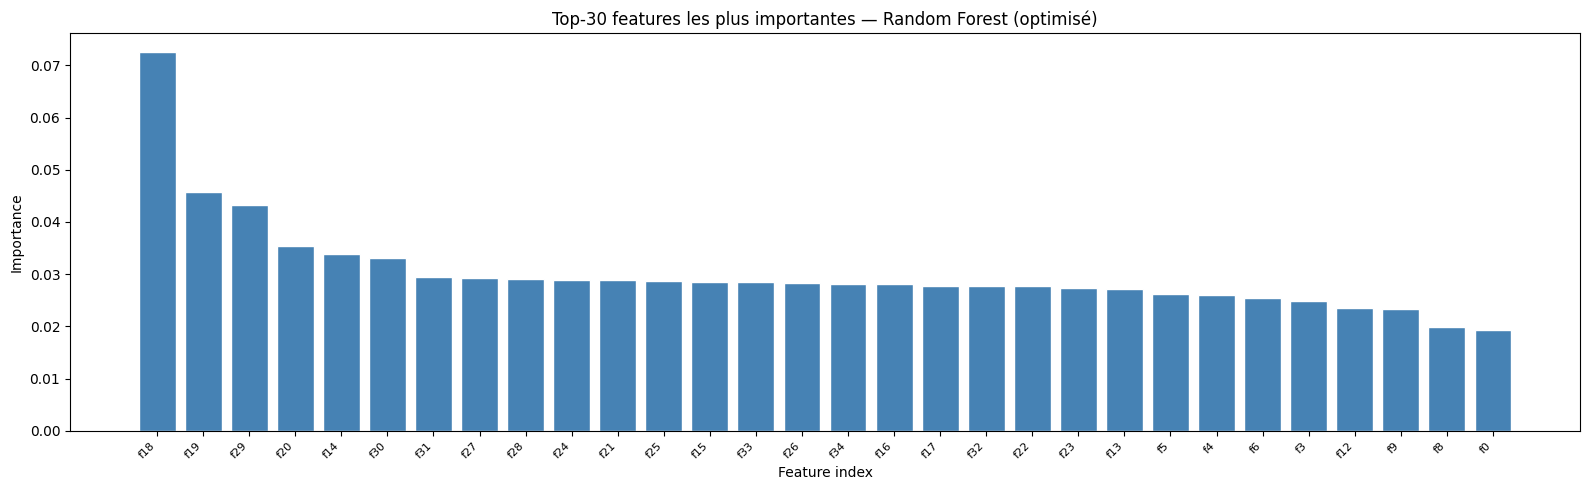


Top-15 features :
   1. [  18] cross_bottom                   imp=0.072593
   2. [  19] cross_lr                       imp=0.045672
   3. [  29] cca_dim_3                      imp=0.043260
   4. [  20] sky_hue                        imp=0.035383
   5. [  14] diff_mean                      imp=0.033950
   6. [  30] cca_dim_4                      imp=0.033076
   7. [  31] cca_dim_5                      imp=0.029423
   8. [  27] cca_dim_1                      imp=0.029180
   9. [  28] cca_dim_2                      imp=0.029085
  10. [  24] cx_norm                        imp=0.028971
  11. [  21] pos_coherence                  imp=0.028860
  12. [  25] cy_norm                        imp=0.028655
  13. [  15] diff_max                       imp=0.028538
  14. [  33] cca_dim_7                      imp=0.028490
  15. [  26] cca_dim_0                      imp=0.028369

✅ Sauvegarde OK.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Pipeline v3 — Résultats finaux
  Test Accuracy : 0.6633


In [13]:
# Importance des features
if hasattr(best_model, 'feature_importances_'):
    imp = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    coef = best_model.coef_
    imp  = np.abs(coef[0] if coef.ndim == 2 else coef)
else:
    imp = None

if imp is not None:
    top_k   = min(30, len(imp))
    top_idx = np.argsort(imp)[::-1][:top_k]

    plt.figure(figsize=(16, 5))
    plt.bar(range(top_k), imp[top_idx], color='steelblue', edgecolor='white')
    plt.xticks(range(top_k), [f'f{i}' for i in top_idx], rotation=45, ha='right', fontsize=8)
    plt.title(f'Top-{top_k} features les plus importantes — {base_name} (optimisé)')
    plt.xlabel('Feature index'); plt.ylabel('Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()

    scalar_names = [
        'dist_cosine','cos_sim','dist_euclidean','dist_manhattan','dist_chebyshev',
        'dist_canberra','dist_braycurtis','dot_product','angle','pearson_r',
        'norm_ratio','proj_scalar','orth_norm','diff_std','diff_mean','diff_max','diff_min',
        'cross_top','cross_bottom','cross_lr','sky_hue','pos_coherence',
        'txt_top*top_hue','txt_bot*bot_hue','cx_norm','cy_norm',
    ]
    print(f'\nTop-15 features :')
    for rank, idx in enumerate(top_idx[:15]):
        name = scalar_names[idx] if idx < len(scalar_names) else f'cca_dim_{idx-len(scalar_names)}'
        print(f'  {rank+1:2d}. [{idx:4d}] {name:<30} imp={imp[idx]:.6f}')

# Sauvegarde
import joblib
joblib.dump(best_model,    'v3_best_model.pkl')
joblib.dump(sc_dist,       'v3_scaler_dist.pkl')
joblib.dump(sc_img,        'v3_scaler_img.pkl')
joblib.dump(sc_text,       'v3_scaler_text.pkl')
joblib.dump(pca_img_pre,   'v3_pca_img.pkl')
joblib.dump(pca_text_pre,  'v3_pca_text.pkl')
joblib.dump(cca,           'v3_cca.pkl')
joblib.dump(tfidf,         'v3_tfidf.pkl')
joblib.dump(vt_img,        'v3_vt_img.pkl')
joblib.dump(vt_text,       'v3_vt_text.pkl')
joblib.dump(selector,      'v3_selector.pkl')
joblib.dump(vt_final,      'v3_vt_final.pkl')
joblib.dump(gs,            'v3_gridsearch.pkl')

print('\n✅ Sauvegarde OK.')
print(f'\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'Pipeline v3 — Résultats finaux')
print(f'  Test Accuracy : {test_acc:.4f}')
print(f'  Test F1       : {test_f1:.4f}')
print(f'  AUC-ROC       : {auc_score:.4f}')
print(f'  Modèle        : {base_name} (GridSearch optimisé)')
print(f'  Paramètres    : {gs.best_params_}')
print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')